In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("../data/processed/final_dataset.csv")

df.head()

,URL,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,NoOfSubDomain,HasObfuscation,...,NoOfCSS,NoOfJS,NoOfExternalRef,label,URL_Length,Dot_Count,Slash_Count,Hyphen_Count,Digit_Count,HasHTTPS
0,https://www.southbankmosaics.com,31,24,0,100.0,1.000000,0.522907,0.061933,1,0,...,20,28,124,1,32,2,2,0,0,1
1,https://www.uni-mainz.de,23,16,0,100.0,0.666667,0.032650,0.050207,1,0,...,9,8,217,1,24,2,2,1,0,1
2,https://www.voicefmradio.co.uk,29,22,0,100.0,0.866667,0.028555,0.064129,2,0,...,2,7,5,1,30,3,2,0,0,1
3,https://www.sfnmjournal.com,26,19,0,100.0,1.000000,0.522907,0.057606,1,0,...,27,15,31,1,27,2,2,0,0,1
4,https://www.rewildingargentina.org,33,26,0,100.0,1.000000,0.079963,0.059441,1,0,...,15,34,85,1,34,2,2,0,0,1


In [3]:
X = df.drop(columns=["URL", "label"])

y = df["label"]

print(X.shape)
print(y.shape)

(235795, 40)
(235795,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [6]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,URLSimilarityIndex,0.235541
33,NoOfExternalRef,0.200268
30,NoOfImage,0.126436
32,NoOfJS,0.061582
22,HasSocialNet,0.057833
31,NoOfCSS,0.051108
29,HasCopyrightInfo,0.045205
21,HasDescription,0.044622
36,Slash_Count,0.035641
12,NoOfOtherSpecialCharsInURL,0.024306


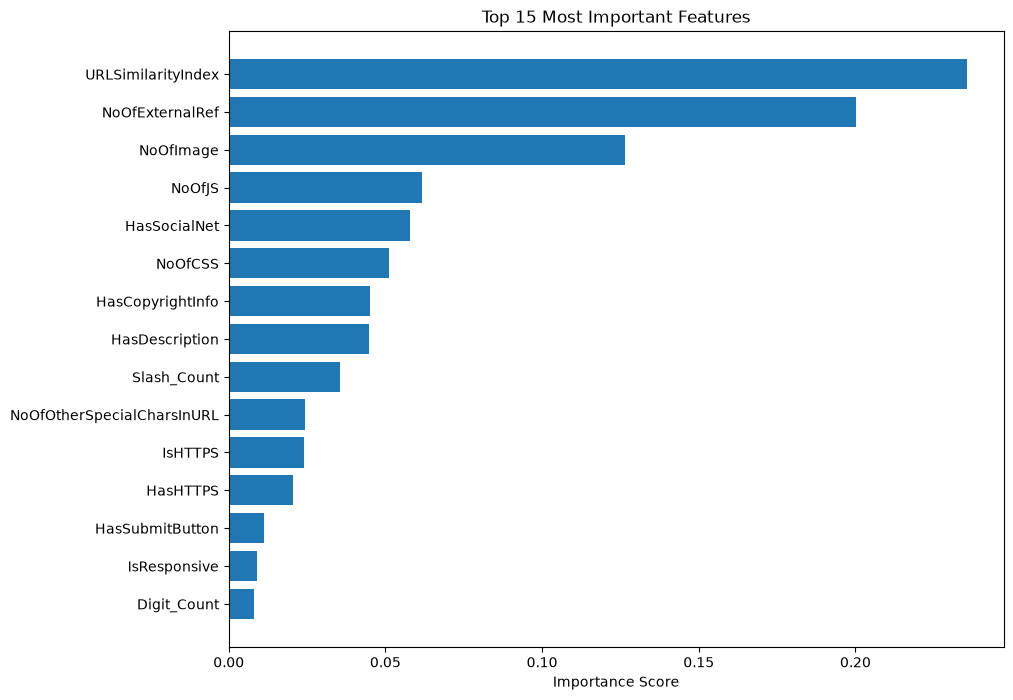

In [7]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()

plt.show()

In [8]:
feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

print("Feature Importance Saved Successfully")

Feature Importance Saved Successfully
